# Estudio de métodos tabulares para el aprendizaje por refuerzo en entornos discretos

## Introducción

Dentro del aprendizaje por refuerzo podemos distinguir dos tipos de problemas fundamentales: los problemas de predicción, que consisten en evaluar cómo de buena es una política dada, y los problemas de control, cuyo objetivo es mejorar la política de un agente, llegando idealmente a una política óptima para un determinado entorno (esto es, una política que maximice las recompensas obtenidas). Siempre que el número de estados y acciones sea finito podemos emplear métodos tabulares para resolver estos problemas, que son aquellos que utilizan una tabla de valores que cuantifican la calidad de un determinado estado, en el caso de la predicción, o de un par estado-acción, en el caso del control.

En este notebook nos centraremos en el problema de control, donde las tablas que se utilizan son las denominadas tablas de **valores Q**. Estos valores Q son las recompensas a largo plazo que el agente espera recibir si toma una determinada acción en un estado concreto. El flujo de aprendizaje de un agente es el siguiente:

1. El agente observa el estado en el que se encuentra.
2. En función de su política, toma una acción.
3. Esta acción actualiza el entorno y genera un nuevo estado y una recompensa instantánea.
4. La nueva información se le pasa al algoritmo de aprendizaje para actualizar los valores Q. Esta actualización se puede realizar en cada paso, cada *n* pasos, o al final del episodio.

Esto se repite hasta que el agente alcanza un estado terminal, lo que marca el fin del episodio. El proceso se repite durante un cierto número de episodios hasta que, idealmente, la política del agente converge a una solución óptima.

El objetivo de este notebook es comparar diversos algoritmos de aprendizaje; en concreto, se han implementado los siguientes métodos tabulares: Monte Carlo On y Off policy, Q-Learning, SARSA, SARSA esperado, SARSA de n pasos y Doble Q-Learning. Para facilitar el proceso de aprendizaje y con el objeto de que el código fuese lo más modular posible, se han implementado cuatro módulos dentro del directorio ``./src/``:

- ``Plotting``: contiene todas las funciones que usaremos para representar gráficamente el aprendizaje y los resultados de cada algoritmo.
- ``Policies``: incluye varias políticas que los agentes pueden usar. Se han implementado las políticas greedy, $\epsilon$-greedy y $\epsilon$-decay. Todas ellas heredan de una clase abstracta que incluye un método para seleccionar una acción dado un estado y una tabla Q, así como métodos para calcular la probabilidad de seleccionar cada una de las acciones en un cierto estado y el valor de recompensa esperada en un estado.
- ``Learners``: en él se definen todos los algoritmos de aprendizaje que hemos mencionado antes, los cuales heredan de una clase abstracta que incluye un método para inicializar el episodio, un método que se ejecuta en cada paso del aprendizaje y uno que realiza una actualización al final del episodio en caso de que sea necesario (por ejemplo, en Monte Carlo). También incorpora una función para resetear el algoritmo en cada ejecución.
- ``Agents``: este módulo contiene una clase Agent que representa al agente, que es quien interactúa con el entorno tomando acciones en base a una política, recibe recompensas y recopila estadísiticas durante el aprendizaje. Este agente es totalmente agnóstico al algoritmo de aprendizaje y a la política: el bucle de aprendizaje es siempre el mismo.

También hay un módulo ``utils``, pero éste no es relevante para el desarrollo de los métodos tabulares, sino que es utilizado en el estudio de los métodos aproximados.

## Preparación del entorno

In [ ]:
import os

if os.getenv("COLAB_RELEASE_TAG"):
    print("Ejecutando en Colab")
    !git clone https://github.com/mlucasumu/EML_RL_LucasOrtiz.git
    %cd EML_RL_LucasOrtiz/entornos_complejos
else:
   print("Ejecutando en local")

In [ ]:
# Librerías necesarias para el setup
import sys

# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\eml-venv', '', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\eml-venv\\Lib\\site-packages', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\EML_RL_LucasOrtiz\\entornos_complejos\\src']


In [ ]:
# Importación de librerías y módulos
import gymnasium as gym
import numpy as np

from agents import Agent
from learners import QLearning, SARSA, MCOnPolicy, nStepSARSAonPolicy, ExpectedSARSA, DoubleQLearning, MCOffPolicy
from policies import EpsilonGreedyPolicy, EpsilonDecayPolicy
from plotting import plotting

## Entorno de Gymnasium

En cuanto al entorno de la librería Gymnasium, hemos decidido emplear el entorno denominado ***"Cliff Walking"*** dado que éste es uno de los que se utilizan en el libro de Sutton y Barto y, por tanto, podemos tratar de replicar algunos de los resultados que los autores obtienen. El entorno es un mundo grid de tamaño 4x12 en el que el agente empieza en la casilla [3, 0] y debe llegar a la [3, 11]. En la tercera fila hay un acantilado desde la columna 1 hasta la 10 y, si el agente se mueve a alguna de esas casillas, recibe una recompensa de -100 y vuelve a la posición inicial. En cualquier otra casilla a la que se mueva, el agente recibe una recompensa de -1. En consecuencia, el número de acciones que se pueden tomar es cuatro (moverse hacia arriba, abajo, izquierda o derecha), y el número de observaciones es 3*12+1, puesto que el agente solo puede estar en una de las tres primeras filas o en la posición inicial.

In [ ]:
env = gym.make('CliffWalking-v1')
env = gym.wrappers.TimeLimit(env, max_episode_steps=1000)
state_size = env.observation_space.n
action_size = env.action_space.n

Como vemos en la celda anterior, hemos decidido usar el Wrapper ``TimeLimit`` para limitar a 1000 el número de pasos que se pueden dar en cada episodio. Si un agente no logra llegar al estado terminal en menos de 1000 pasos, el episodio se trunca y se pasa al siguiente episodio.

## Entrenamientos con parámetros comunes

Para la mayoría de los entrenamientos que vamos a realizar, usaremos los siguientes parámetros (a no ser que se especifique lo contrario):

- Tasa de aprendizaje $\alpha$ constante de $0.5$, salvo en Monte Carlo, en el que no usamos un $\alpha$ constante.
- Tasa de descuento $\gamma$ de $0.95$.
- Siempre que use una política $\epsilon$-greedy, el valor de $\epsilon$ será de $0.1$.
- En caso de usar una política $\epsilon$-decay, la tasa de decaimiento sería de $0.9999$ (en nuestro caso, el decaimiento se calcula como $\epsilon\cdot\text{decay\_rate}$).
- El número de episodios en cada ejecución será de 400, y los resultados serán la media de 10 ejecuciones.

A continuación definimos estos parámetros, así como las políticas, algoritmos de aprendizaje y agentes:

In [5]:
alpha = 0.5 # Tasa de aprendizaje
gamma = 0.95 # Tasa de descuento (importancia que el agente proporciona a futuras recompensas)
epsilon = 0.1 # Probabilidad de exploración en la política
n_steps = 5 # Para diferencias temporales de n pasos
decay_rate = 0.9999 # Para epsilon decay (eps*decay)
num_episodes = 400 # Nº de episodios por ejecución
n_runs = 10 # Nº de ejecuciones (los resultados serán la media de ellas)
SEED = 123 # Reproducibilidad

policy = EpsilonGreedyPolicy(epsilon)
policy_decay = EpsilonDecayPolicy(decay_rate=decay_rate, min_epsilon=0.1)

learner_qlearning = QLearning(state_size, action_size, alpha, gamma)
learner_sarsa = SARSA(state_size, action_size, alpha, gamma, policy)
learner_mconpolicy = MCOnPolicy(state_size, action_size, gamma)
learner_mconpolicy_first = MCOnPolicy(state_size, action_size, gamma, first_visit=True)
learner_nstep_sarsa = nStepSARSAonPolicy(state_size, action_size, alpha, gamma, policy, n_steps)
learner_expected_sarsa = ExpectedSARSA(state_size, action_size, alpha, gamma, policy)
learner_doubleq = DoubleQLearning(state_size, action_size, alpha, gamma) 
learner_mcoffpolicy = MCOffPolicy(state_size, action_size, gamma, behavior_policy=policy)

agent_qlearning = Agent(env, learner_qlearning, policy)
agent_sarsa = Agent(env, learner_sarsa, policy)
agent_mconpolicy = Agent(env, learner_mconpolicy, policy)
agent_mconpolicy_first = Agent(env, learner_mconpolicy_first, policy)
agent_nstep_sarsa = Agent(env, learner_nstep_sarsa, policy)
agent_expected_sarsa = Agent(env, learner_expected_sarsa, policy)
agent_doubleq = Agent(env, learner_doubleq, policy)
agent_mcoffpolicy = Agent(env, learner_mcoffpolicy, policy)

Ahora, realizamos un entrenamiento por cada tipo de agente:

In [6]:
qtable_qlearning, rewards_qlearning, episode_lengths_qlearning, stats_qlearning = agent_qlearning.train(num_episodes, n_runs, SEED)
qtable_sarsa, rewards_sarsa, episode_lengths_sarsa, stats_sarsa = agent_sarsa.train(num_episodes, n_runs, SEED)
qtable_expected_sarsa, rewards_expected_sarsa, episode_lengths_expected_sarsa, stats_expected_sarsa = agent_expected_sarsa.train(num_episodes, n_runs, SEED)
qtable_nstep_sarsa, rewards_nstep_sarsa, episode_lengths_nstep_sarsa, stats_nstep_sarsa = agent_nstep_sarsa.train(num_episodes, n_runs, SEED)
qtable_doubleq, rewards_doubleq, episode_lengths_doubleq, stats_doubleq = agent_doubleq.train(num_episodes, n_runs, SEED)
qtable_mconpolicy, rewards_mconpolicy, episode_lengths_mconpolicy, stats_mconpolicy = agent_mconpolicy.train(num_episodes, n_runs, SEED)
qtable_mconpolicy_first, rewards_mconpolicy_first, episode_lengths_mconpolicy_first, stats_mconpolicy_first = agent_mconpolicy_first.train(num_episodes, n_runs, SEED)
qtable_mcoffpolicy, rewards_mcoffpolicy, episode_lengths_mcoffpolicy, stats_mcoffpolicy = agent_mcoffpolicy.train(num_episodes, n_runs, SEED)

100%|██████████| 10/10 [02:41<00:00, 16.11s/it]


## Resultados y análisis

En esta sección vamos a realizar diversas comparativas entre los algoritmos de aprendizaje que se han implementado.

### SARSA vs Q Learning: recompensas y ruta óptima

En primer lugar, vamos a comparar los algoritmos de difencias temporales SARSA y Q-Learning.

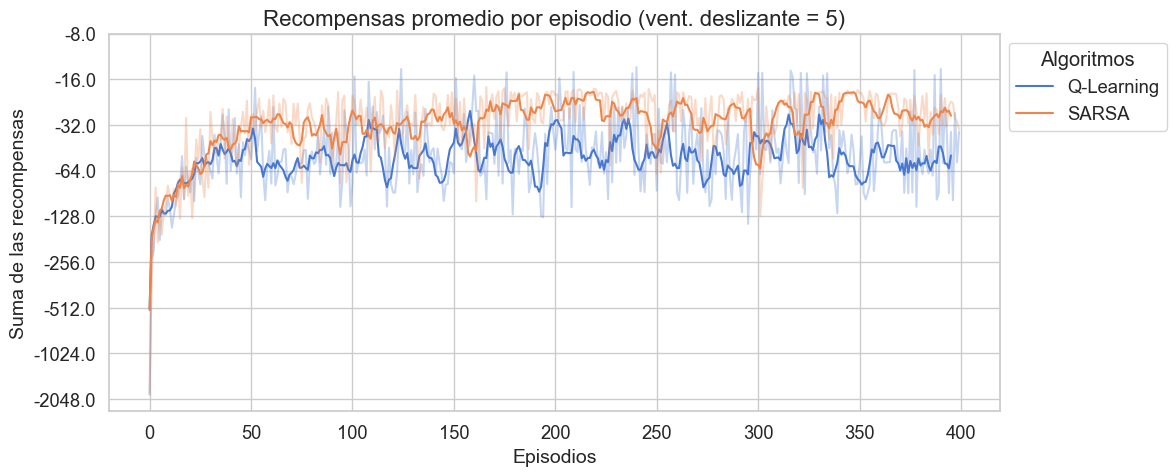

In [7]:
plotting.plot_rewards([rewards_qlearning, rewards_sarsa],
                      ["Q-Learning", "SARSA"],
                      log_scale=True,
                      rolling_window=5)

Como vemos en la gráfica de recompensas promedio, los resultados encajan perfectamente con lo que se muestra en el libro de Sutton y Barto: la recompensa promedio de SARSA se mantiene consistentemente por encima de Q-Learning. Además, si mostramos los valores medios obtenidos en los últimos episodios, vemos lo siguiente:

In [8]:
print("Media de las recompensas de los últimos 50 episodios:")
print("qlearning:", rewards_qlearning[-50:].mean())
print("sarsa:", rewards_sarsa[-50:].mean())

Media de las recompensas de los últimos 50 episodios:
qlearning: -55.908
sarsa: -26.592000000000002


El método Q-Learning obtiene una recompensa de alrededor de -50, mientras que SARSA obtiene valores en torno a -25. Esto es exactamente lo que se aprecia en la gráfica mostrada en el libro de Sutton y Barto.

A continuación se muestra la longitud promedio de cada episodio:

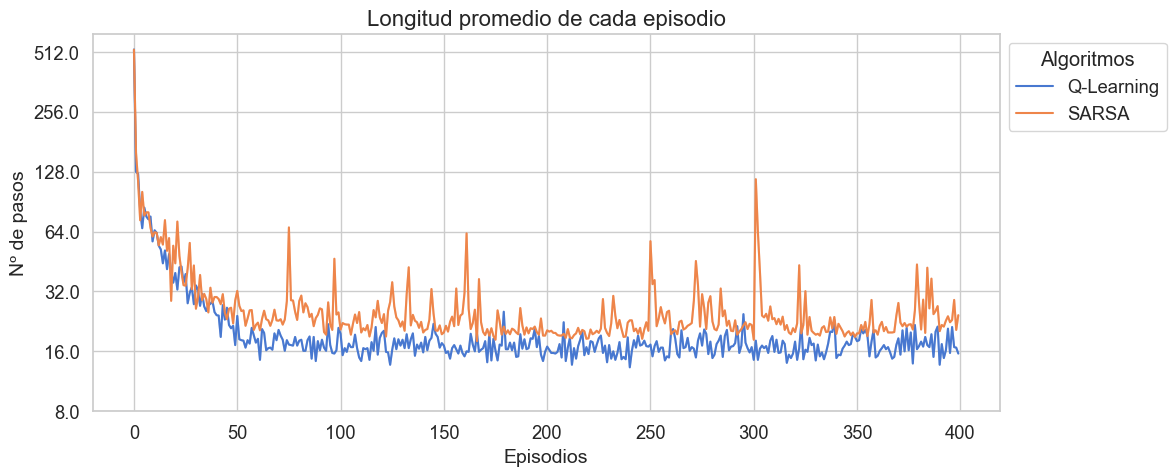

In [9]:
plotting.plot_episode_lengths([episode_lengths_qlearning, episode_lengths_sarsa],
                                ["Q-Learning", "SARSA"],
                                log_scale=True,
                                rolling_window=1)

Observamos que, a pesar de que las recompensas promedio con SARSA eran superiores a Q-Learning, SARSA realiza de media un mayor número de pasos. Esto tiene que ver con la política aprendida por cada agente, en la cual SARSA aprende una ruta más larga pero más segura, por lo que casi nunca se cae por el acantilado, mientras que Q-Learning aprende una ruta más corta pero cercana al acantilado, por lo que existe una probabilidad de que se caiga por el acantilado (al usar una política $\epsilon$-greedy), disminuyendo así la recompensa promedio.

A continuación se muestran las dos políticas greedy generadas por cada algoritmo:

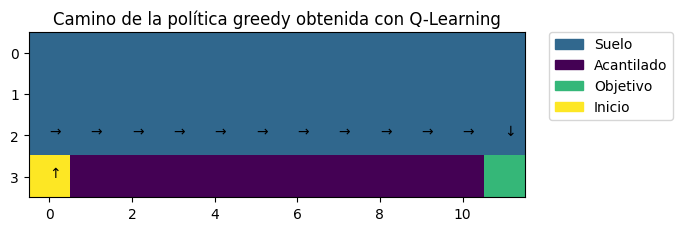

In [10]:
plotting.plot_optimal_path_CliffWalker(qtable_qlearning, algorithm_name="Q-Learning")

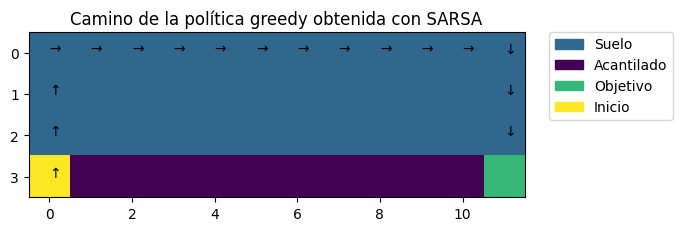

In [11]:
plotting.plot_optimal_path_CliffWalker(qtable_sarsa, algorithm_name="SARSA")

Por último, mostramos el error de entrenamiento promedio por episodio:

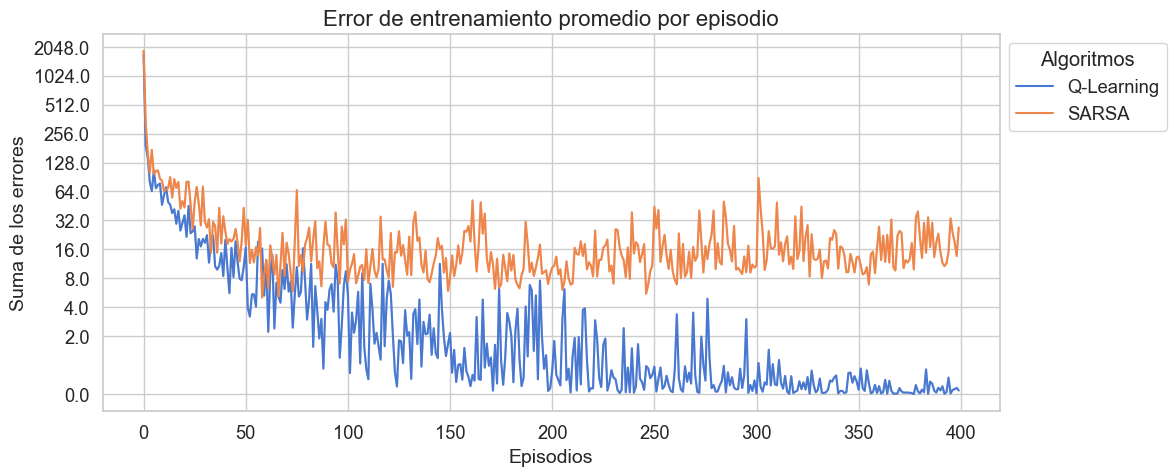

In [12]:
plotting.plot_training_errors([stats_qlearning['cum_training_error'], stats_sarsa['cum_training_error']],
                                ["Q-Learning", "SARSA"],
                                log_scale=True,
                                rolling_window=1)

Observamos que SARSA tiene un mayor error de entrenamiento a lo largo de todos los episodios, lo cual es razonable ya que, como utiliza la política del agente (que es $\epsilon$-greedy), siempre hay un porcentaje de ocasiones en el que escoge acciones poco favorables (de modo que la nueva recompensa difiere mucho de la recompensa estimada).

### Versiones de SARSA

Ahora, compararemos tres versiones del método SARSA: SARSA "estándar" de un paso, SARSA de 5 pasos, y SARSA esperado.

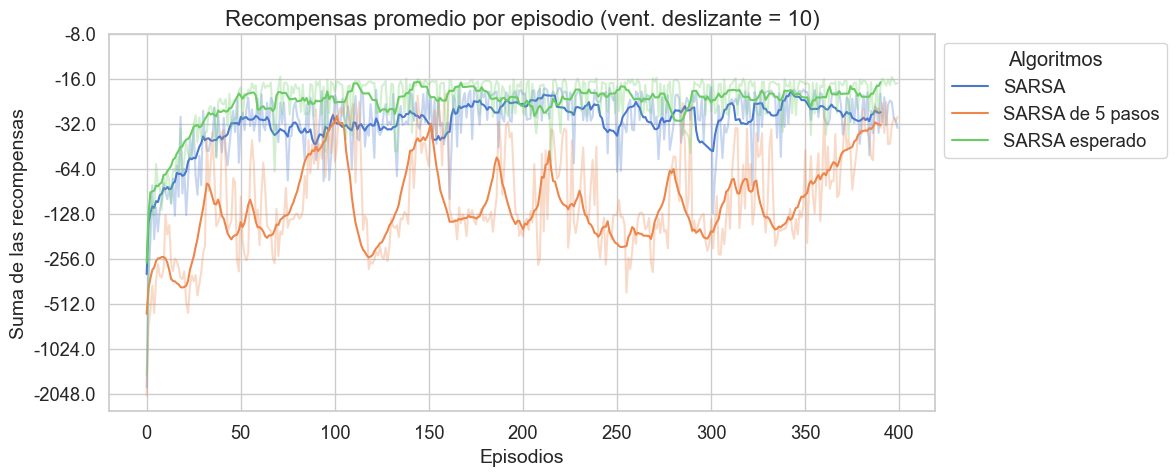

In [13]:
plotting.plot_rewards([rewards_sarsa, rewards_nstep_sarsa, rewards_expected_sarsa], 
             legend_labels=["SARSA", "SARSA de 5 pasos", "SARSA esperado"], 
             log_scale=True,
             rolling_window=10)

Por un lado, observamos que SARSA esperado es el que mejor rendimiento ofrece, con un aprendizaje muy rápido y una convergencia a una solución prácticamente óptima. Por otro lado, vemos que SARSA de 5 pasos presenta una varianza mucho más grande y un rendimiento más pobre. En cuanto a la varianza, es normal que un método que tiene en cuenta más pasos futuros tenga una mayor varianza pero, a cambio, presenta menor sesgo. En cuanto al rendimiento, vemos que las recompensas se mantienen consistentemente por debajo de los otros dos métodos, posiblemente porque, al tener una varianza más alta, requeriría un mayor número de episodios para converger a una buena solución.

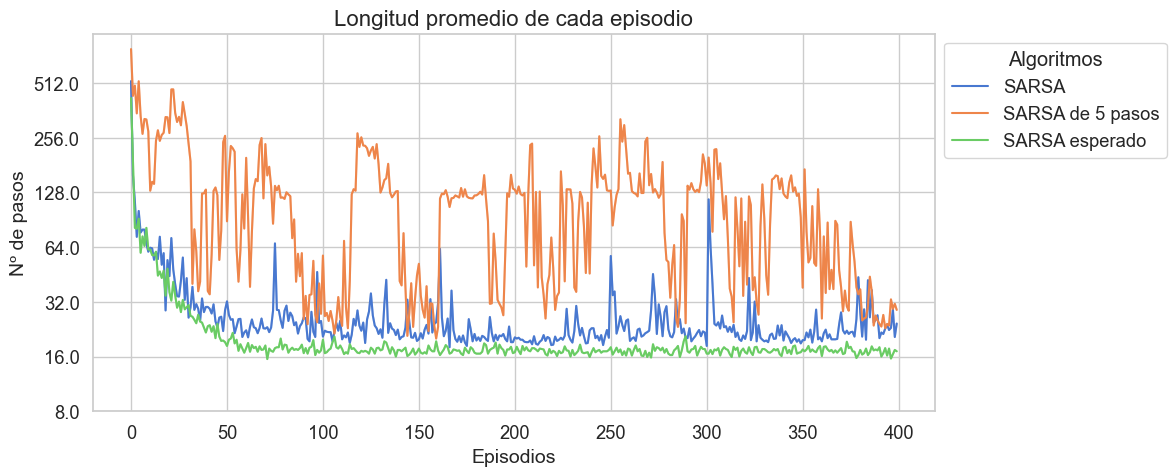

In [163]:
plotting.plot_episode_lengths([episode_lengths_sarsa, episode_lengths_nstep_sarsa, episode_lengths_expected_sarsa], 
             legend_labels=["SARSA", "SARSA de 5 pasos", "SARSA esperado"], 
             log_scale=True,
             rolling_window=1)

La longitud promedio de los episodios muestra la misma tendencia que las recompensas: SARSA esperado presenta una menor longitud promedio, de alrededor de 15 (prácticamente el menor número de pasos que se pueden dar), mientras que SARSA de 5 pasos es el que más pasos suele tardar en completar los episodios, con una varianza muy elevada.

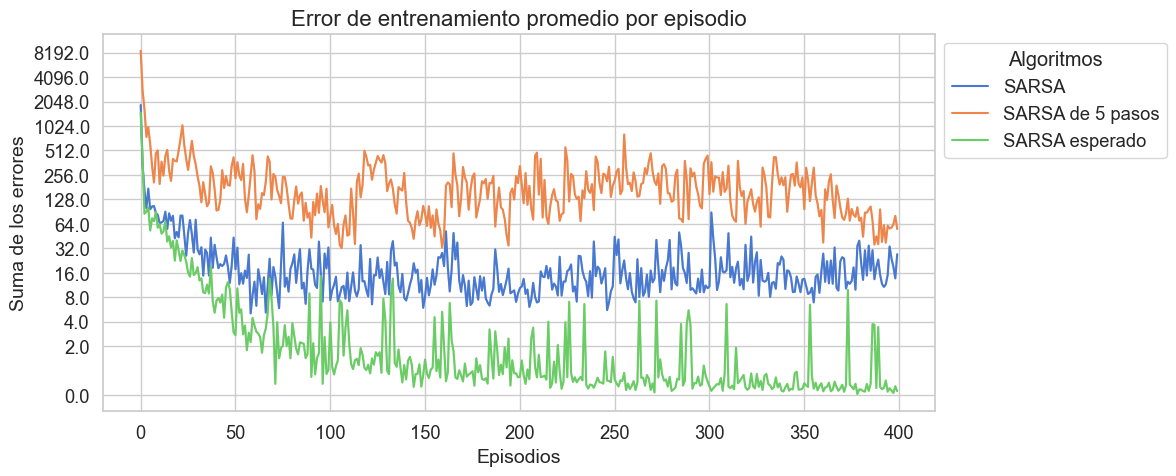

In [53]:
plotting.plot_training_errors([stats_sarsa['cum_training_error'], stats_nstep_sarsa['cum_training_error'], stats_expected_sarsa['cum_training_error']], 
             legend_labels=["SARSA", "SARSA de 5 pasos", "SARSA esperado"], 
             log_scale=True,
             rolling_window=1)

En cuanto a los errores de entrenamiento, SARSA esperado vuelve a demostrar su superioridad frente a los otros dos algoritmos.

Por último, es interesante mostrar la ruta obtenida utilizando la política greedy generada por SARSA esperado. Como vemos en la siguiente celda, el camino es un punto intermedio entre los que obteníamos con SARSA y Q-Learning: no es ni la ruta más arriesgada, ni la más cautelosa.

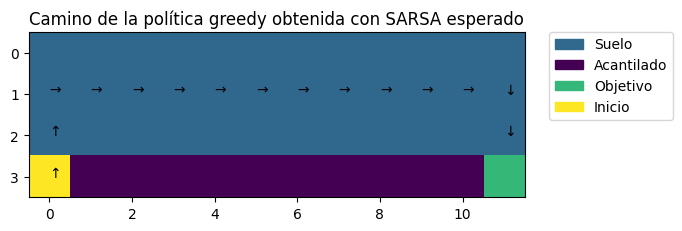

In [175]:
plotting.plot_optimal_path_CliffWalker(qtable_expected_sarsa, algorithm_name="SARSA esperado")

### SARSA vs Expected SARSA en función del alpha

En esta sección se comparan los algoritmos de SARSA y SARSA esperado en función del valor del parámetro $\alpha$ (tasa de aprendizaje).

In [69]:
alpha_values = np.arange(0.1, 1, 0.1)
alpha_results = {}

for a in alpha_values:
    sarsa = Agent(env,
                  SARSA(state_size, action_size, a, gamma, policy),
                  policy)
    expected_sarsa = Agent(env,
                        ExpectedSARSA(state_size, action_size, a, gamma, policy),
                        policy)
    
    sarsa_qtable, sarsa_rewards, sarsa_episode_lengths, sarsa_stats = sarsa.train(num_episodes, n_runs, SEED)
    expected_sarsa_qtable, expected_sarsa_rewards, expected_sarsa_episode_lengths, expected_sarsa_stats = expected_sarsa.train(num_episodes, n_runs, SEED)

    alpha_results[a] = {
        'SARSA': {
            'qtable': sarsa_qtable, 
            'rewards': sarsa_rewards,
            'episode_lengths': sarsa_episode_lengths,
            'cum_errors': sarsa_stats['cum_training_error']
        }
        ,
        'Expected SARSA': {
            'qtable': expected_sarsa_qtable, 
            'rewards': expected_sarsa_rewards,
            'episode_lengths': expected_sarsa_episode_lengths,
            'cum_errors': expected_sarsa_stats['cum_training_error']
        }
    }

100%|██████████| 10/10 [00:05<00:00,  1.94it/s]


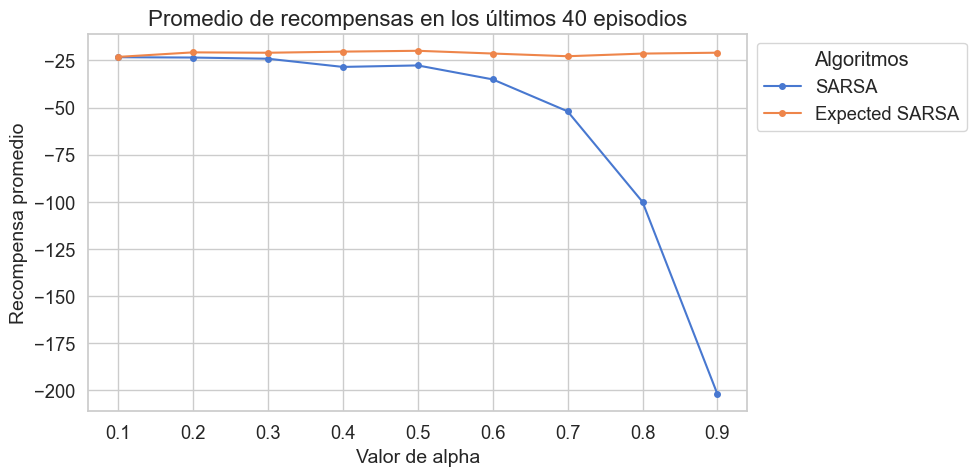

In [ ]:
plotting.plot_average_reward_per_alpha(alpha_results, last_episodes_ratio=0.1, log_scale=False)

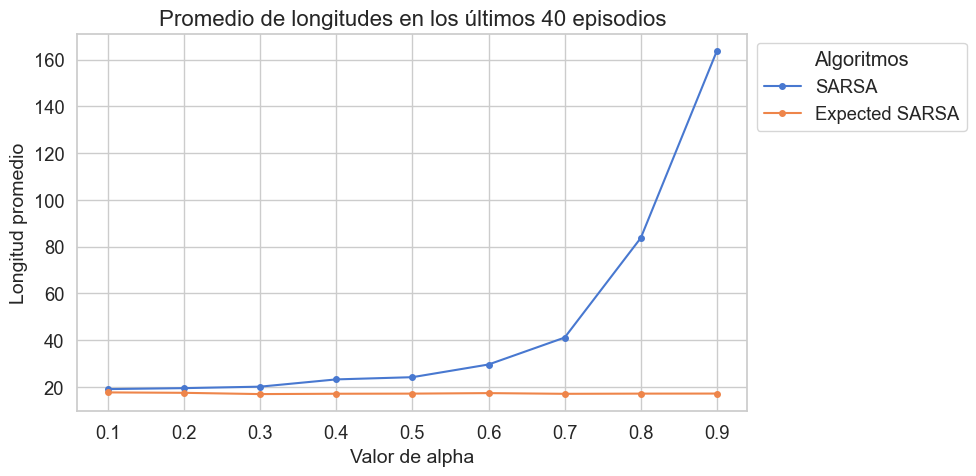

In [ ]:
plotting.plot_average_episode_length_per_alpha(alpha_results, last_episodes_ratio=0.1, log_scale=False)

Los resultados que obtenemos son muy similares a los que se ven en el libro de Sutton y Barto: el rendimiento de SARSA esperado, tanto en las recompensas promedio como en las longitudes de los episodios, se mantiene elevado independientemente del valor de $\alpha$, mientras que SARSA de un paso sí presenta una degradación del rendimiento conforme $\alpha$ aumenta. Por ejemplo, con $\alpha=0.9$, SARSA esperado mantiene una recompensa promedio superior a -25, mientras que SARSA se desploma a una recompensa de -200. Notamos que estos promedios se calculan con el último 10% de los episodios, una vez los algoritmos ya han convergido.

### n-step SARSA en función del nº de pasos

A continuación, vamos a analizar el comportamiento de SARSA de n pasos en función del número de pasos.

In [ ]:
nstep_values = np.arange(2, 11, 1)
nstep_results = {}

for n in nstep_values:
    agent = Agent(env,
                  nStepSARSAonPolicy(state_size, action_size, alpha, gamma, policy, n), # alpha de 0.5 como al principio
                  policy)
    
    qtable, rewards, episode_lengths, stats = agent.train(num_episodes, n_runs, SEED)

    nstep_results[n] = {
        'qtable': qtable, 
        'rewards': rewards,
        'episode_lengths': episode_lengths,
        'cum_errors': stats['cum_training_error']
    }

100%|██████████| 10/10 [01:10<00:00,  7.06s/it]


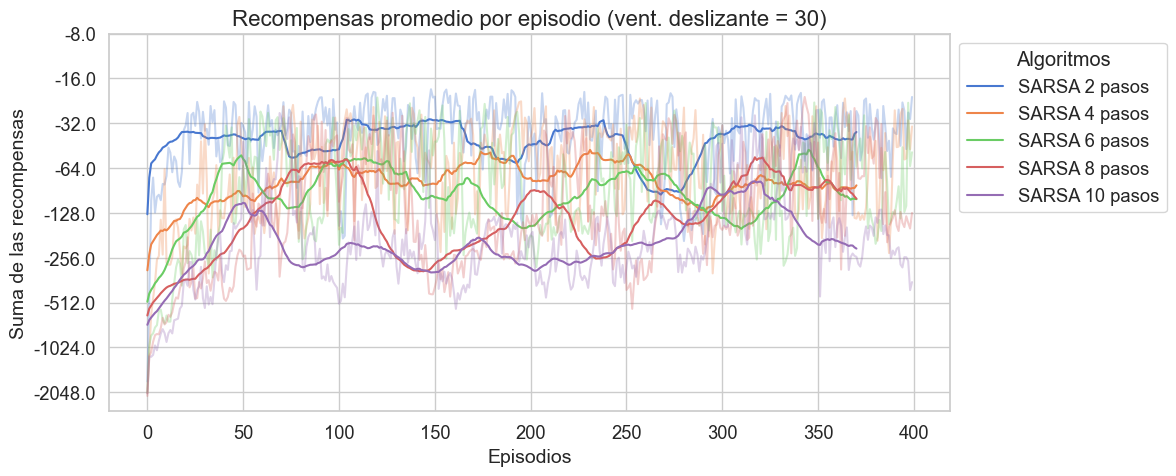

In [150]:
plotting.plot_rewards([results['rewards'] for n, results in nstep_results.items()][0:len(nstep_values):2], 
             legend_labels=[f"SARSA {n} pasos" for n in nstep_results.keys()][0:len(nstep_values):2], 
             log_scale=True,
             rolling_window=30)

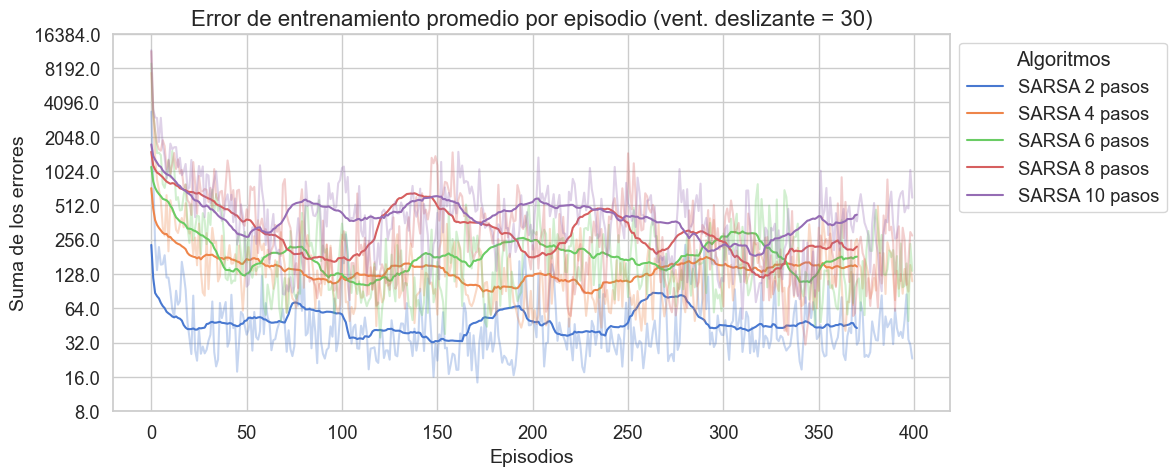

In [164]:
plotting.plot_training_errors([results['cum_errors'] for n, results in nstep_results.items()][0:len(nstep_values):2], 
             legend_labels=[f"SARSA {n} pasos" for n in nstep_results.keys()][0:len(nstep_values):2], 
             log_scale=True,
             rolling_window=30)

En las dos gráficas anteriores, que muestran la evolución de las recompensas y los errores de entrenamiento promedio de los episodios para cinco valores de $n$, observamos que SARSA de 2 pasos es el que mantiene una mayor recompensa promedio y menor error de entrenamiento, mientras que los valores de $n$ más grandes suelen ofrecer peores resultados. Vemos, además, que a mayor valor de $n$, mayor varianza. Cabe plantearse si el desempeño de estos algoritmos sería diferente con otros valores de la tasa de aprendizaje, o si se mantendría la misma tendencia. Por tanto, a continuación vamos a ejecutar algunas versiones de SARSA de $n$ pasos con diversos valores de $\alpha$:

In [ ]:
alpha_values = np.arange(0.1, 1, 0.1)
nstep_values = [2,5,7,10]
alpha_nsteps_results = {}

for a in alpha_values:
    alpha_nsteps_results[a] = {}
    for n in nstep_values:
        agent = Agent(env,
                      nStepSARSAonPolicy(state_size, action_size, a, gamma, policy, n),
                      policy)

    
        qtable, rewards, episode_lengths, stats = agent.train(num_episodes, n_runs, SEED)

        alpha_nsteps_results[a][f'SARSA {n} pasos'] = {
            'qtable': qtable, 
            'rewards': rewards,
            'episode_lengths': episode_lengths,
            'cum_errors': stats['cum_training_error']
        }

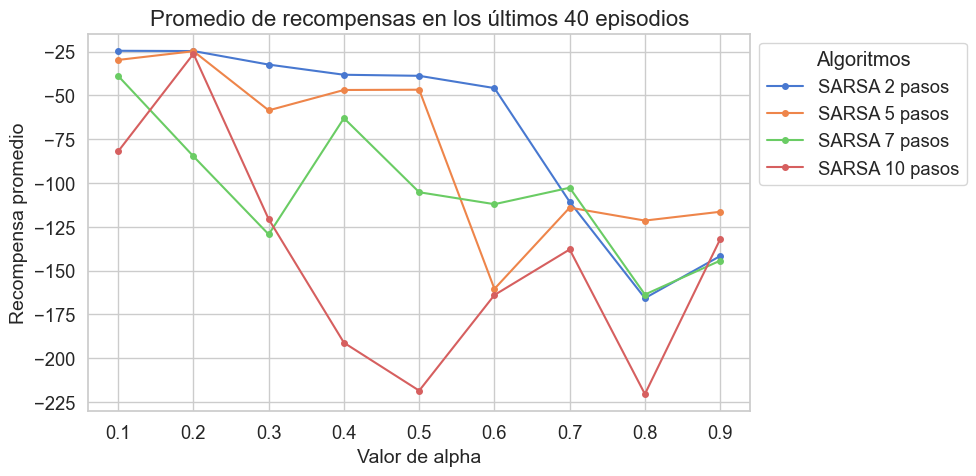

In [28]:
plotting.plot_average_reward_per_alpha(alpha_nsteps_results, last_episodes_ratio=0.1, log_scale=False)

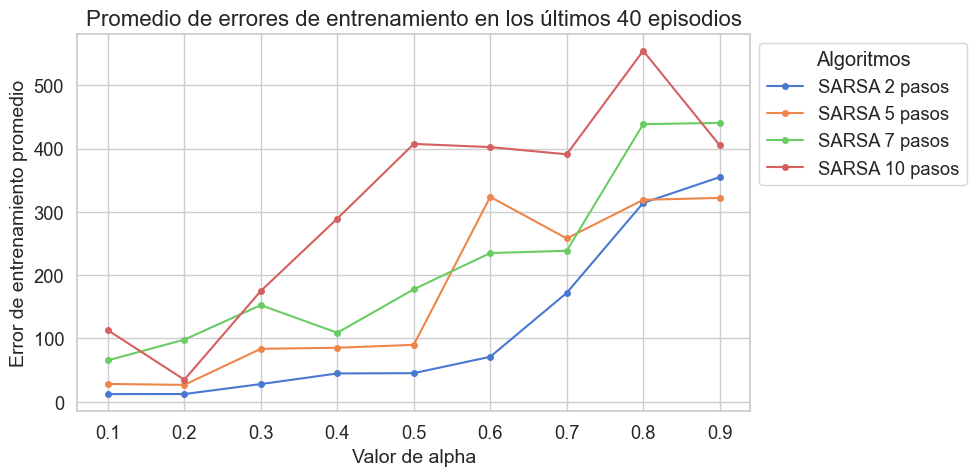

In [34]:
plotting.plot_average_error_per_alpha(alpha_nsteps_results, last_episodes_ratio=0.1, log_scale=False)

Como vemos, la tendencia se mantiene para prácticamente todos los valores de $\alpha$: a menor número de pasos, las recompensas promedio y los errores de entrenamiento son menores. Solo en los valores más elevados de la tasa de aprendizaje se aprecia un sutil cambio, dado que SARSA de 5 pasos comienza a ser ligeramente mejor que SARSA de 2 pasos, y SARSA de 10 pasos mejora sus resultados con respecto a SARSA de 7 pasos.

### Q-Learning vs Doble Q-Learning

Para finalizar con los métodos de diferencias temporales, analicemos cómo se comporta Doble Q-Learning en contraposición a Q-Learning "estándar":

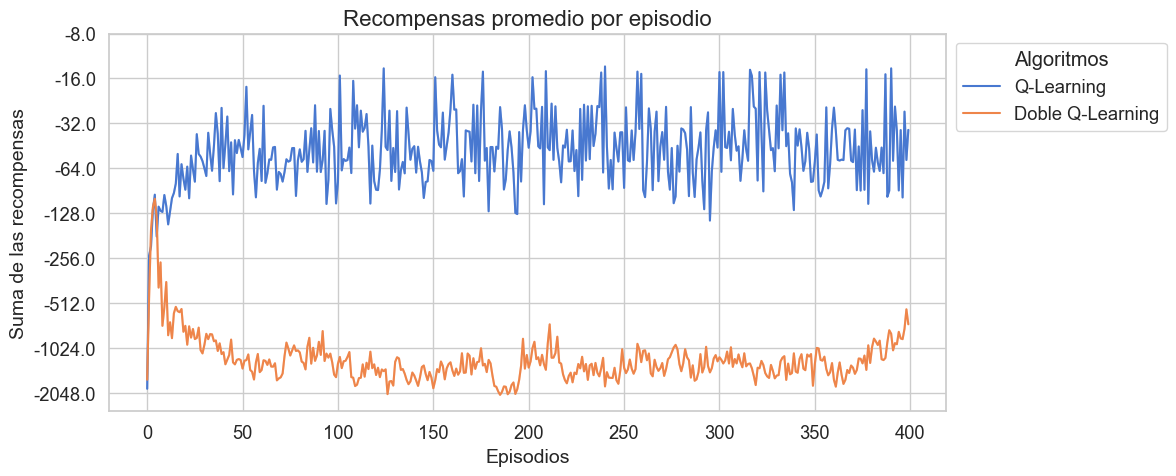

In [40]:
plotting.plot_rewards([rewards_qlearning, rewards_doubleq], 
             legend_labels=["Q-Learning", "Doble Q-Learning"], 
             log_scale=True,
             rolling_window=1)

Como vemos en la gráfica anterior, da la impresión de que Doble Q-Learning no solo no está aprendiendo al mismo ritmo que Q-Learning, sino que sus resultados *empeoran* cuantos más episodios se realizan. Esto podría indicar que se ha producido algún error en la implementación, sin embargo, tras una búsqueda en Internet, comprobamos que este es un problema que ya le ha sucedido a algunos usuarios, como se puede ver en [esta](https://stats.stackexchange.com/questions/514477/why-does-double-q-learning-converge-so-slowly) publicación. En ella, el autor muestra una gráfica en la que, al igual que en la nuestra, se aprecia que Doble Q-Learning empeora sus recompensas promedio mientras que Q-Learning las mejora. A continuación, el usuario comenta que, tras dejar el algoritmo en ejecución durante un mayor número de episodios, los resultados comenzaron a mejorar. Por ende, vamos a ejecutar el algoritmo durante 10000 episodios, en lugar de solo 400, para verificar si el agente logra alcanzar unos resultados similares a los de Q-Learning. Para acelerar la ejecución, haremos solo 2 runs en lugar de 10.

In [43]:
qtable_doubleq_v2, rewards_doubleq_v2, episode_lengths_doubleq_v2, stats_doubleq_v2 = agent_doubleq.train(num_episodes=10000, n_runs=2, seed=SEED)

100%|██████████| 2/2 [07:57<00:00, 238.94s/it]


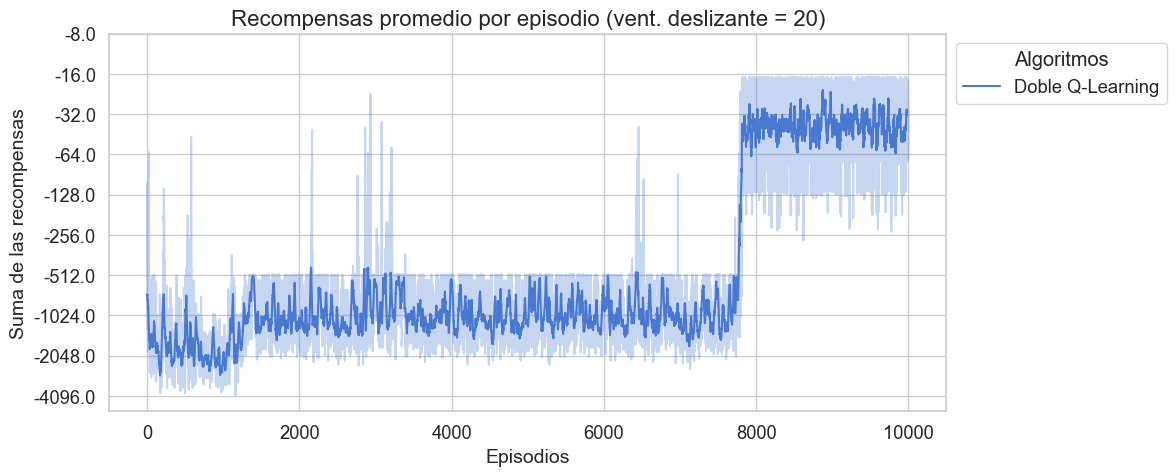

In [45]:
plotting.plot_rewards([rewards_doubleq_v2], 
             legend_labels=["Doble Q-Learning"], 
             log_scale=True,
             rolling_window=20)

Efectivamente, tras 10000 episodios, el agente ha logrado alcanzar una solución similarmente buena a la obtenida con el algoritmo Q-Learning (realmente, la alcanza alrededor del episodio 8000). Además, podemos observar dos instantes donde la recompensa promedio aumenta radicalmente: alrededor del episodio 1700, en el que las recompensas pasan de ser -2000 a -1000, aproximadamente, y poco antes del episodio 8000, en el que la recompensa promedio vuelve a aumentar en unos 1000 puntos. En cuanto al por qué de estos "saltos" tan repentinos, no hemos logrado averiguar el motivo por el que se producen. Cabe destacar, además, que decidimos que las dos tablas Q se actualizaran por turnos, en lugar de aleatoriamente, para tratar de evitar que se descompensaran demasiado.

Es posible que uno de los motivos de su aprendizaje tan lento sea que el algoritmo requiere una mayor exploración, sobre todo en los primeros episodios, para no quedarse "atascado" en rutas subóptimas. En consecuencia, vamos a probar a utilizar un agente que emplee una política $\epsilon$-decay, en lugar de una $\epsilon$-greedy, que comience con una tasa de exploración de $1.0$, tenga una tasa de decaimiento de $0.9999$ y un $\epsilon$ mínimo de 0.1. El número de pasos que tendrán que darse hasta decaer el $\epsilon$ por completo es:

$$ 0.9999^n = 0.1 \Rightarrow n = \log_{0.9999}0.1 \approx 23024 \text{ pasos} $$

In [8]:
agent_doubleq_decay = Agent(env, learner_doubleq, policy_decay)
qtable_doubleq_v3, rewards_doubleq_v3, episode_lengths_doubleq_v3, stats_doubleq_v3 = agent_doubleq_decay.train(num_episodes=10000, n_runs=2, seed=SEED)

100%|██████████| 2/2 [01:57<00:00, 58.97s/it]


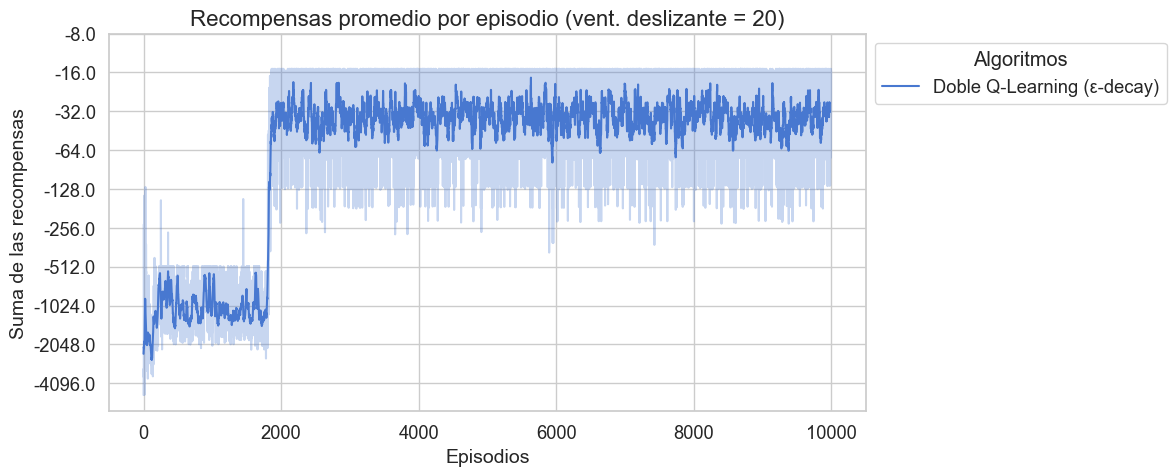

In [30]:
plotting.plot_rewards([rewards_doubleq_v3], 
             legend_labels=["Doble Q-Learning (ε-decay)"], 
             log_scale=True,
             rolling_window=20)

Efectivamente, nuestra intuición era correcta: con una política $\epsilon$-decay parametrizada tal y como hemos descrito previamente, el rendimiento del algoritmo es significativamente mayor. Ahora, el agente tarda menos de 2000 pasos en alcanzar una recompensa promedio similar a la obtenida con Q-Learning, en contraposición con los casi 8000 que tardaba antes. Mostremos la gráfica sin usar escala logarítmica en el eje Y:

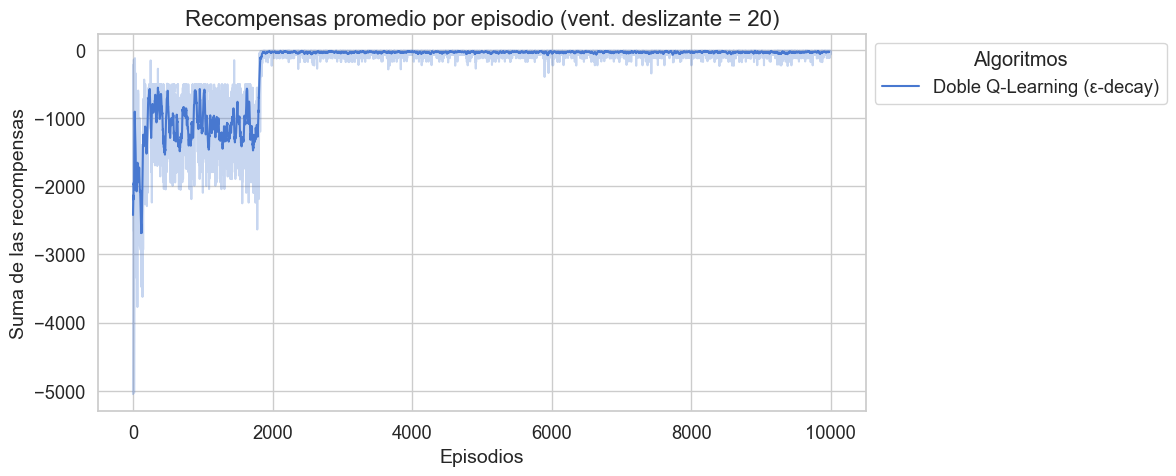

In [31]:
plotting.plot_rewards([rewards_doubleq_v3], 
             legend_labels=["Doble Q-Learning (ε-decay)"], 
             log_scale=False,
             rolling_window=20)

Como vemos, el algoritmo es muy inestable al principio, con recompensas promedio que presentan una enorme varianza; sin embargo, que una vez converge, muestra un comportamiento similar a Q-Learning estándar. Con respecto a la longitud promedio de los episodios, observamos lo siguiente:

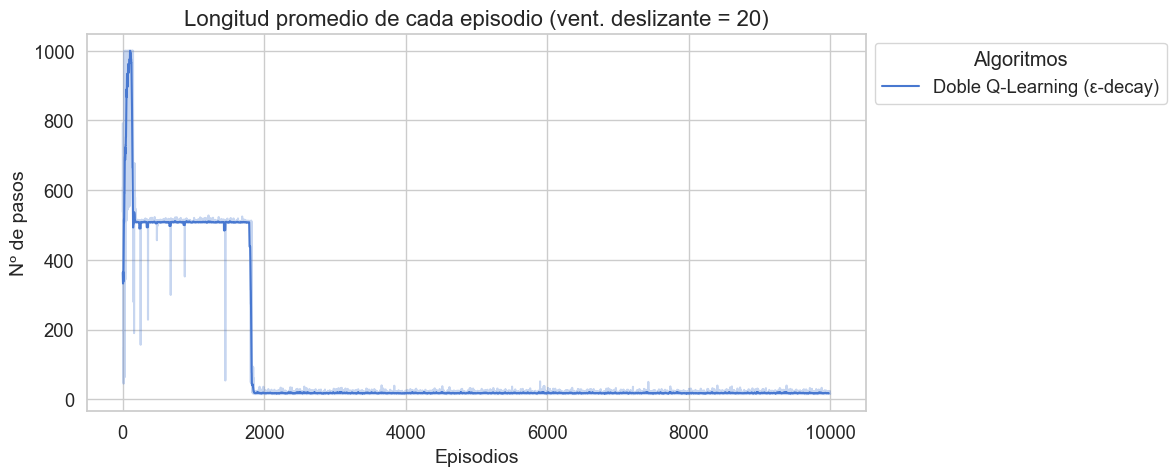

In [27]:
plotting.plot_episode_lengths([episode_lengths_doubleq_v3], 
             legend_labels=["Doble Q-Learning (ε-decay)"], 
             log_scale=False,
             rolling_window=20)

Se aprecian tres etapas claras: en los primeros episodios, el agente no es capaz de llegar al objetivo, por lo que los episodios son truncados a los 1000 pasos. Luego, se estabiliza en longitudes promedio de unos 500 pasos, lo que indica que el agente da muchas vueltas sin llegar a la meta, probablemente cayéndose con frecuencia en el acantilado. A partir del episodio 1900, aproximadamente, el agente por fin logra aprender una ruta definitiva que le conduce al objetivo. Dicha ruta, si usáramos una política greedy, sería la siguiente:

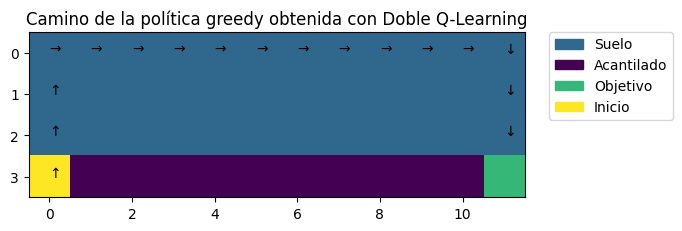

In [22]:
plotting.plot_optimal_path_CliffWalker(learner_doubleq.qtable, "Doble Q-Learning")

Curiosamente, es la misma ruta que obteníamos con SARSA, y no la ruta más arriesgada aprendida por Q-Learning.

### Monte Carlo vs TD

Pasemos ahora a analizar los métodos de Monte Carlo. En primer lugar, vamos a comparar Monte Carlo On Policy (de todas las visitas) con uno de los métodos de Diferencias Temporales, en concreto, con SARSA Esperado, que ha sido el algoritmo de TD que mejores resultados ha dado.

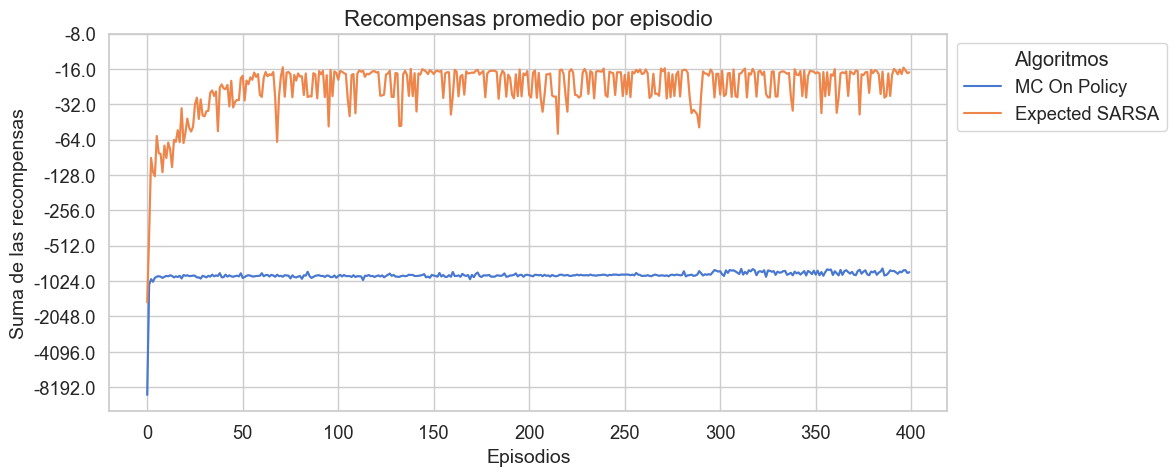

In [169]:
plotting.plot_rewards([rewards_mconpolicy, rewards_expected_sarsa], 
             legend_labels=["MC On Policy", "Expected SARSA"], 
             log_scale=True,
             rolling_window=1)

Claramente, Monte Carlo tiene un comportamiento mucho peor que diferencias temporales en este problema: aprende más lentamente, parece estancarse en una solución subóptima (aunque quizás necesitaría más episodios para continuar con su aprendizaje) y, además, el tiempo de ejecución es notablemente superior.

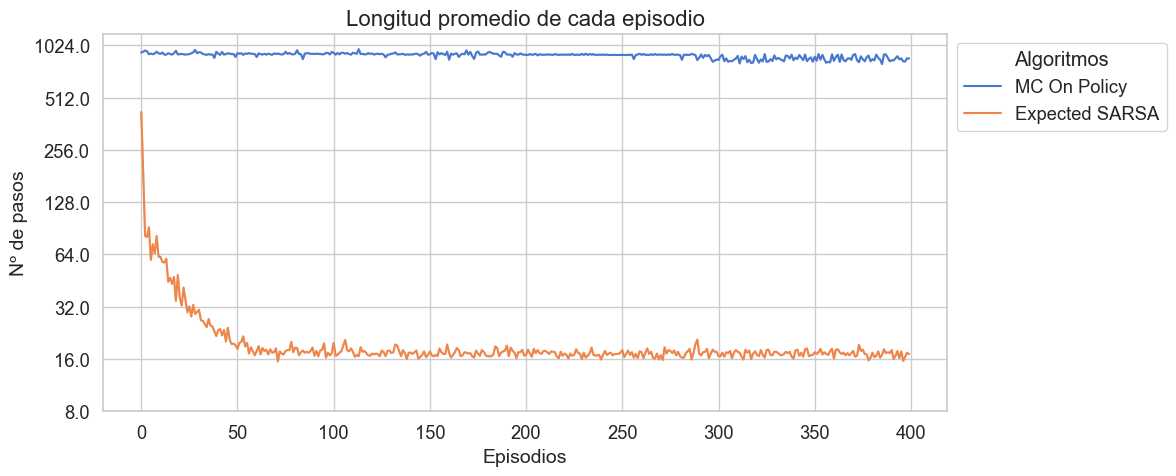

In [151]:
plotting.plot_episode_lengths([episode_lengths_mconpolicy, episode_lengths_expected_sarsa], 
             legend_labels=["MC On Policy", "Expected SARSA"], 
             log_scale=True,
             rolling_window=1)

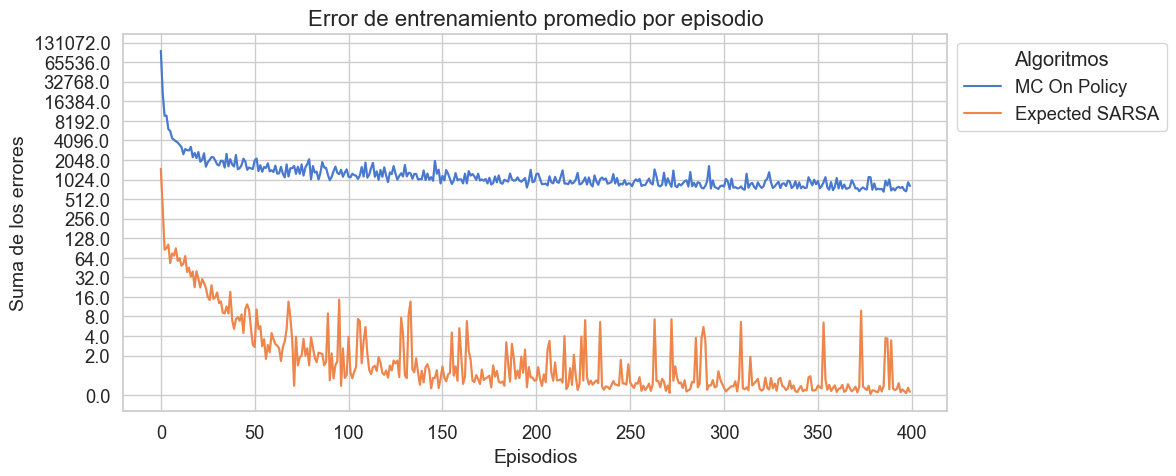

In [152]:
plotting.plot_training_errors([stats_mconpolicy['cum_training_error'], stats_expected_sarsa['cum_training_error']], 
             legend_labels=["MC On Policy", "Expected SARSA"], 
             log_scale=True,
             rolling_window=1)

Las gráficas de longitudes promedio y error de entrenamiento confirman lo que hemos dicho previamente: los episodios con el agente que usa Monte Carlo son mucho más largos que con diferencias temporales, estando alrededor de los 900 pasos, y los errores de entrenamiento también son bastante más altos. Se puede apreciar una ligera tendencia a la baja en la gráfica de errores de entrenamiento, lo que indica que el algoritmo sigue en proceso de aprendizaje, si bien es muy lento debido, seguramente, a la gran varianza que presentan los métodos de Monte Carlo. Esto lo compensan teniendo un menor sesgo, en especial Monte Carlo de primera visita, que usa estimadores *insesgados*.

### Versiones de Monte Carlo

Finalmente, se comparan tres versiones del método de Monte Carlo: MC On Policy de todas las visitas, MC On Policy de primera vista y MC Off Policy (con muestreo de importancia ponderado).

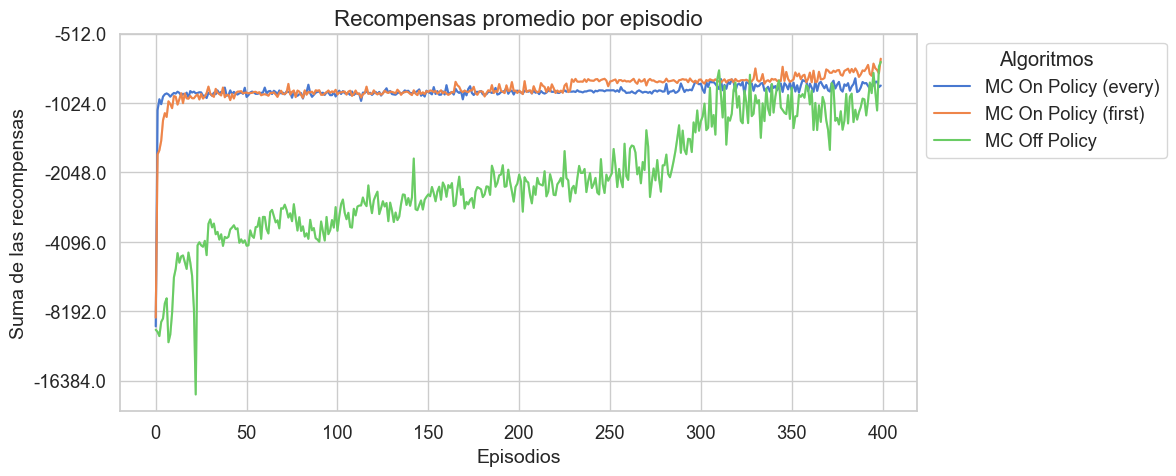

In [154]:
plotting.plot_rewards([rewards_mconpolicy, rewards_mconpolicy_first, rewards_mcoffpolicy], 
             legend_labels=["MC On Policy (every)", "MC On Policy (first)", "MC Off Policy"], 
             log_scale=True,
             rolling_window=1)

En la gráfica de recompensas promedio podemos apreciar varias cosas: por un lado, vemos que el rendimiento de las dos versiones de MC On Policy en cuanto a recompensas es prácticamente idéntico en los primeros 230 episodios, aproximadamente, hasta que MC de primera visita empieza a superar al de todas las visitas, mostrando una pendiente mayor. En cuanto a MC Off Policy, vemos que presenta una mayor varianza, lo cual encaja perfectamente con la teoría, que nos dice que las estimaciones del muestreo de importancia pueden tener varianza infinita (no acotada), si bien el muestreo *ponderado* reduce bastante la varianza. Además, se observa que MC Off Policy comienza en recompensas bastante inferiores, pero su velocidad de aprendizaje es mucho mayor, alcanzando a MC On Policy en los últimos episodios.

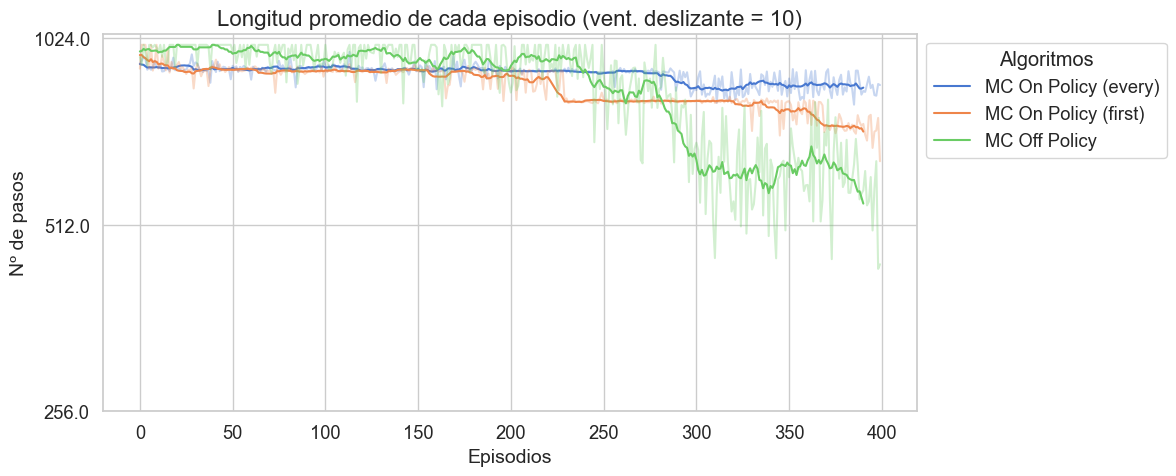

In [155]:
plotting.plot_episode_lengths([episode_lengths_mconpolicy, episode_lengths_mconpolicy_first, episode_lengths_mcoffpolicy], 
             legend_labels=["MC On Policy (every)", "MC On Policy (first)", "MC Off Policy"], 
             log_scale=True,
             rolling_window=10)

Como vemos en la gráfica de longitudes promedio, las dos versiones de MC On Policy van a la par hasta el episodio 200, en el que MC de primera visita empieza a generar episodios más cortos. Esto explica que MC de primera visita tenga mejores recompensas en la segunda mitad de la ejecución, como veíamos antes. Con respecto a MC Off Policy, vemos que ya antes del episodio 300 este método comienza a generar episodios más cortos que MC On Policy y, sin embargo, su recompensa promedio seguía siendo inferior hasta los últimos episodios. Esto indica que MC Off Policy probablemente está siguiendo rutas más cortas pero más cercanas al precipicio, lo que hace que de vez en cuando el agente se caiga en el barranco y la recompensa promedio disminuya.

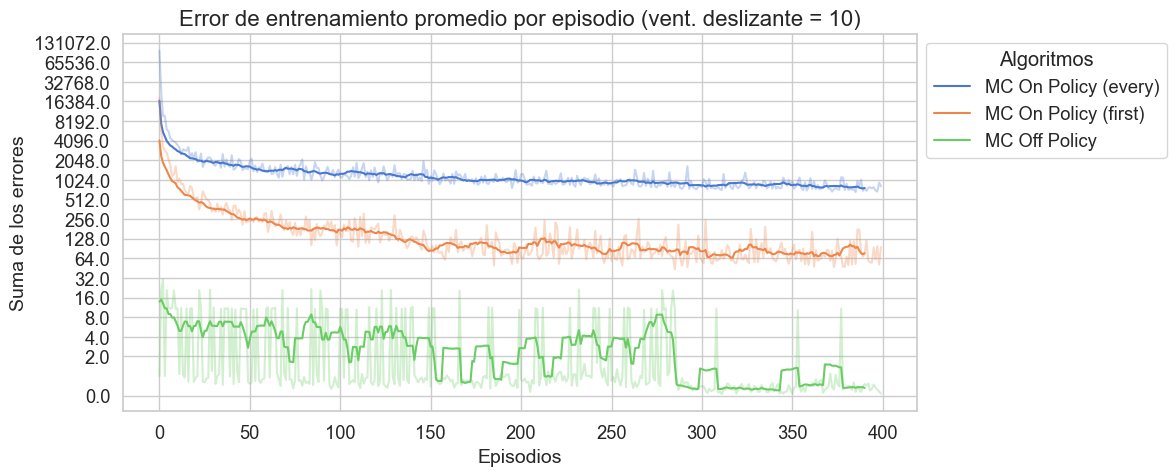

In [161]:
plotting.plot_training_errors([stats_mconpolicy['cum_training_error'], stats_mconpolicy_first['cum_training_error'], stats_mcoffpolicy['cum_training_error']], 
             legend_labels=["MC On Policy (every)", "MC On Policy (first)", "MC Off Policy"], 
             log_scale=True,
             rolling_window=10)

En cuanto al error de entrenamiento, se aprecia que MC de primera visita mantiene un error más bajo que MC de todas las visitas, lo cual probablemente se debe al hecho de que el primer método usa estimadores insesgados, mientras que MC de todas las visitas tiene más sesgo. Por otra parte, MC Off Policy es el que menor error presenta, lo cual es sorprendente dado que los métodos Off-Policy tienden a cometer más error en sus estimaciones, aunque esto depende del problema concreto.

# Conclusiones

A lo largo de este estudio se han analizado diversos métodos tabulares para resolver el problema de control de aprendizaje por refuerzo en el entorno Cliff Walking. Para ello, se han realizado una serie de entrenamientos utilizando una parametrización común para poder comparar los métodos entre sí, además de un análisis más detallado de algunos parámetros, como la tasa de aprendizaje, en algunos de los algoritmos. En concreto, los métodos implementados y estudiados han sido:

1. Diferencias Temporales (TD): Q-Learning, Doble Q-Learning, SARSA, SARSA esperado, SARSA de $n$ pasos.
2. Monte Carlo (MC): MC On Policy de primera visita, MC On Policy de todas las visitas y MC Off Policy con muestreo de importancia ponderado.

Tras ejecutar y analizar el rendimiento de estos algoritmos, hemos podido extraer las siguientes conclusiones:

- Los métodos de Monte Carlo presentan un rendimiento muy inferior a Diferencias Temporales, siendo MC Off Policy el más prometedor de los tres, al presentar un menor error de entrenamiento y mayor velocidad de aprendizaje.
- Los métodos de TD On-Policy, esto es, el algoritmo SARSA y sus variantes, parecen mostrar un mejor rendimiento que TD Off-Policy (Q-Learning), obteniendo una mayor recompensa promedio, si bien la ruta obtenida por SARSA es un poco más larga que la generada por Q-Learning, pero es más segura.
- Dentro de las variantes de SARSA, SARSA esperado es la que obtiene mejores resultados con amplia diferencia, presentando una convergencia muy rápida y una recompensa promedio final prácticamente óptima. La ruta obtenida es un punto medio entre SARSA y Q-Learning: ni es la más arriesgada, ni la más cautelosa. Además, su rendimiento se mantiene elevado independientemente del valor de la tasa de aprendizaje $\alpha$, mientras que la calidad de SARSA sí se ve degradada conforme $\alpha$ aumenta.
- Al analizar SARSA de $n$ pasos vimos que, a mayor número de pasos, mayor varianza y (para la mayoría de valores de $\alpha$) peores resultados. Valores de $n$ bajos solían presentar mejores recompensas promedio.
- Doble Q-Learning es considerablemente más lento en aprender que Q-Learning, y converge a la misma solución obtenida por SARSA. Además, vimos que se beneficia mucho del uso de una política $\epsilon$-decay, que permite una mayor exploración en los primeros episodios.

# Referencias

[1] Sutton, R., & Barto, A. (2018). *Reinforcement Learning, second edition: An Introduction.* MIT Press.
https://web.stanford.edu/class/psych209/Readings/SuttonBartoIPRLBook2ndEd.pdf